In [63]:
import numpy as np, matplotlib.pyplot as plt, pandas as pd

Image shape (1600, 1600)


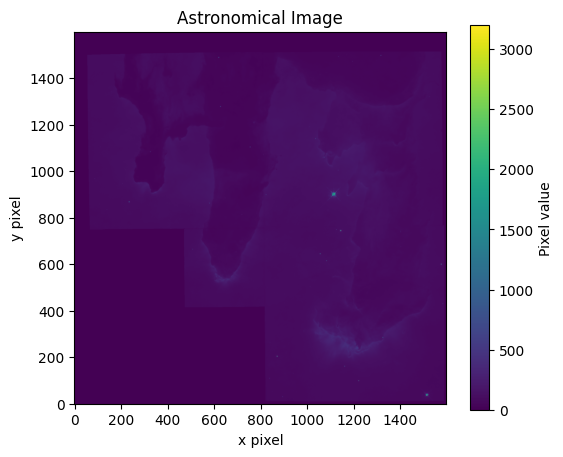

In [64]:
image = np.loadtxt("astro_image.csv")

print("Image shape", image.shape)

plt.figure(figsize=(6,5))
plt.imshow(image, origin="lower")
plt.colorbar(label="Pixel value")
plt.xlabel("x pixel")
plt.ylabel("y pixel")
plt.title("Astronomical Image")
plt.show()


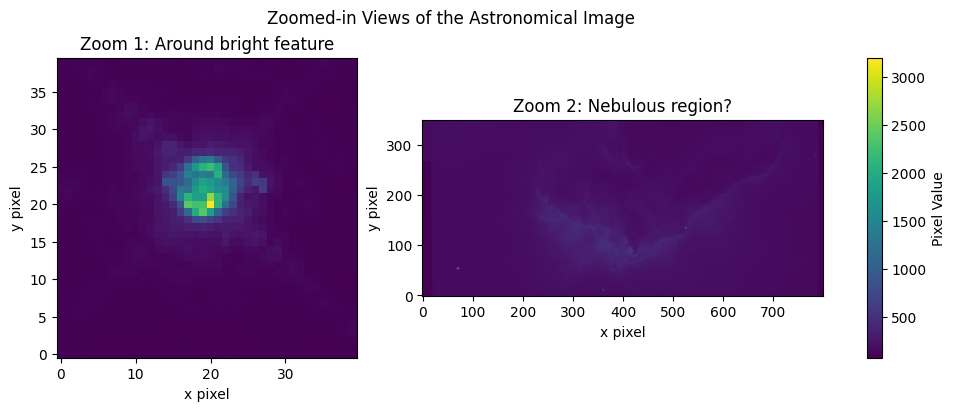

In [65]:
#brightest pixel
max_flat_idx = np.argmax(image)
ny, nx = image.shape
y_max, x_max = divmod(max_flat_idx, nx)

zoomin_size = 20
y_min = max(y_max - zoomin_size, 0)
y_max2 = min(y_max + zoomin_size, ny)
x_min = max(x_max - zoomin_size, 0)
x_max2 = min(x_max + zoomin_size, nx)

zoom1 = image[y_min:y_max2, x_min:x_max2]

#second region (nebulous region?)
zoom2 = image[150:500, 800:1600] 

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

im1 = axes[0].imshow(zoom1, origin="lower")
axes[0].set_title("Zoom 1: Around bright feature")

im2 = axes[1].imshow(zoom2, origin="lower")
axes[1].set_title("Zoom 2: Nebulous region?")

for ax in axes:
    ax.set_xlabel("x pixel")
    ax.set_ylabel("y pixel")

cbar = fig.colorbar(im1, ax=axes)
cbar.set_label("Pixel Value")

plt.suptitle("Zoomed-in Views of the Astronomical Image")
plt.show()



In [66]:
ramen = pd.read_csv("ramen-ratings.csv")

print("="*60)
print("Column names:")
print(ramen.columns.tolist())

print("="*60)
print("Ramen style of 27th entry (index-26):")
print(ramen.iloc[26]["Style"])

print("="*60)
print("Number of unique brands:")
print(ramen["Brand"].nunique())

print("="*60)
print("Sort by brand:")
sorted_ramen = ramen.sort_values("Brand")
display(sorted_ramen)

print("="*60)
print("Number of brands made by USA:")
usa = ramen[ramen["Country"] == "USA"]
print(usa["Brand"].nunique)

print("="*60)
print("Number of USA pack style ramens:")
usa_pack = ramen[(ramen["Country"] == "USA") & (ramen["Style"].str.contains("Pack", na=False))]
print(usa_pack["Brand"].nunique())

print("="*60)
print("Brands ever in T10:")
t10 = ramen[ramen["Top Ten"].notna()]
print(t10["Brand"].unique())


Column names:
['Review #', 'Brand', 'Variety', 'Style', 'Country', 'Stars', 'Top Ten']
Ramen style of 27th entry (index-26):
Pack
Number of unique brands:
355
Sort by brand:


,Review #,Brand,Variety,Style,Country,Stars,Top Ten
229,2351,1 To 3 Noodles,Chatpat Masala,Pack,India,4,NaN
456,2124,7 Select,Nissin Instant Noodles Tom Yum Seafood Creamy ...,Bowl,Thailand,3.5,NaN
463,2117,7 Select,Nissin Instant Noodles Shrimp Ma Nao Lui Suan ...,Bowl,Thailand,4,NaN
877,1703,7 Select/Nissin,Super Tom Yum Shrimp,Cup,Thailand,3.5,NaN
911,1669,A-One,Mi Ly Instant Noodles Mi Chay Vegetarian Flavor,Cup,Vietnam,1.25,NaN
...,...,...,...,...,...,...,...
823,1757,iMee,Instant Noodles Beef Flavour,Pack,Netherlands,3.25,NaN
662,1918,iMee,Instant Noodles chicken Flavour,Pack,Netherlands,3.5,NaN
797,1783,iMee,Instant Noodles Creamy Tom Yum Shrimp Flavour,Pack,Netherlands,4.5,NaN
2135,445,iNoodle,Taiwan Style Chow Mein,Pack,Taiwan,2.25,NaN


Number of brands made by USA:
<bound method IndexOpsMixin.nunique of 2                 Nissin
11              Yamachan
17              Yamachan
21      Jackpot Teriyaki
23              Yamachan
              ...       
2516     Sapporo Ichiban
2546            Maruchan
2557              Nissin
2570               Smack
2579            Westbrae
Name: Brand, Length: 323, dtype: object>
Number of USA pack style ramens:
27
Brands ever in T10:
['MAMA' 'Prima Taste' 'Prima' 'Tseng Noodles' 'Wugudaochang'
 'A-Sha Dry Noodle' 'MyKuali' 'CarJEN' 'Maruchan' 'Mamee' 'Mama'
 'Sapporo Ichiban' 'Nongshim' 'Samyang Foods' 'Paldo' 'Indomie' 'Koka'
 'Mi Sedaap' 'Nissin' 'Myojo' 'Doll']


In [67]:
from astropy.table import Table

In [68]:
t = Table.read("global_CCl4_MM.dat", format="ascii")
print(t.colnames)
df = t.to_pandas()[["CCl4ottoyr", "CCl4ottomon", "CCl4ottoGLm", "CCl4ottoGLsd"]]
df.columns = ["year", "month", "concentration", "sd"]
df.head()

['CCl4ottoyr', 'CCl4ottomon', 'CCl4ottoNHm', 'CCl4ottoNHsd', 'CCl4ottoSHm', 'CCl4ottoSHsd', 'CCl4ottoGLm', 'CCl4ottoGLsd']


,year,month,concentration,sd
0,1996,1,NaN,NaN
1,1996,2,NaN,NaN
2,1996,3,NaN,NaN
3,1996,4,104.144,0.155
4,1996,5,103.893,0.174


In [69]:
df["date"] = df["year"] + (df["month"] - 1) / 12
df = df.dropna()

df.head()



,year,month,concentration,sd,date
3,1996,4,104.144,0.155,1996.250000
4,1996,5,103.893,0.174,1996.333333
5,1996,6,104.207,0.191,1996.416667
6,1996,7,104.136,0.147,1996.500000
7,1996,8,103.836,0.161,1996.583333


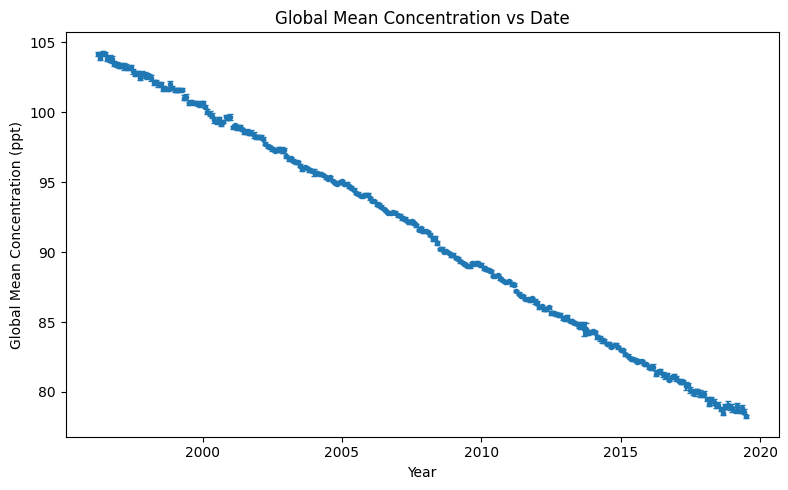

In [70]:
x = df["date"]
y = df["concentration"]
yerr = df["sd"]

plt.figure(figsize=(8, 5))
plt.errorbar(x, y, yerr=yerr, fmt=".", capsize=2)
plt.xlabel("Year")
plt.ylabel("Global Mean Concentration (ppt)")
plt.title("Global Mean Concentration vs Date")
plt.tight_layout()
plt.show()

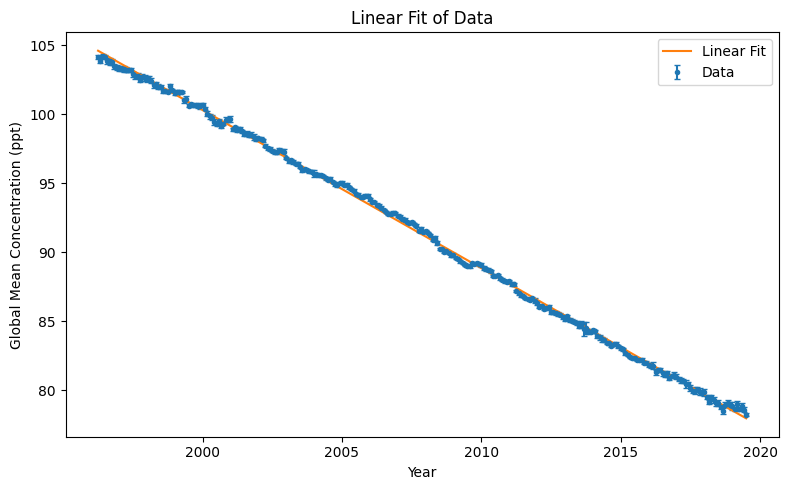

In [71]:
coef = np.polyfit(x, y, 1)
poly = np.poly1d(coef)

y_model = poly(x)

plt.figure(figsize=(8, 5))
plt.errorbar(x, y, yerr=yerr, fmt=".", capsize=2, label="Data")
plt.plot(x, y_model, label="Linear Fit")
plt.xlabel("Year")
plt.ylabel("Global Mean Concentration (ppt)")
plt.title("Linear Fit of Data")
plt.legend()
plt.tight_layout()
plt.show()

In [72]:
N = len(df)
p = 2  

residuals = y_model - y
chi2 = np.sum((residuals / yerr)**2)
reduced_chi2 = chi2 / (N - p)

chi2, reduced_chi2

(np.float64(1280.6870510272302), np.float64(4.606787953335361))

DATA PRESENTATION
Raw chi2 value :  1280.6870510272302 
Reduced chi2 value :  4.606787953335361
------------------------------------------------------------
Linear model fit to the Global mean CCl4 Concentration as a function of Time:


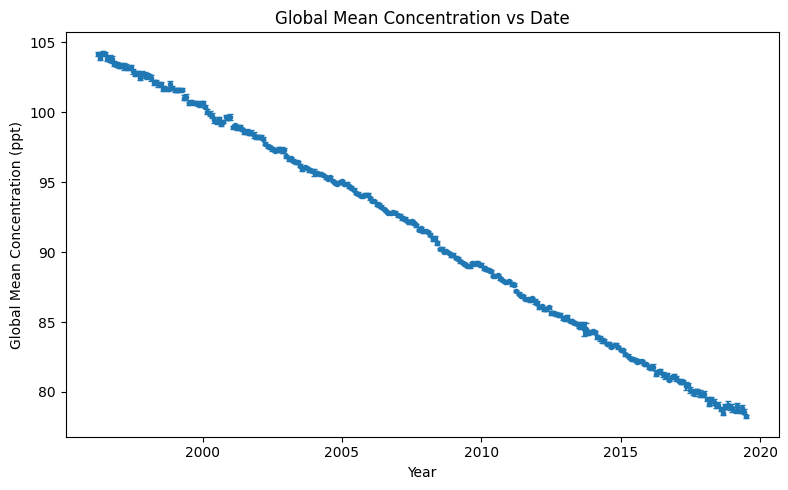

In [73]:
#presentation 
print("="*30)
print("DATA PRESENTATION")
print("="*30)

print('Raw chi2 value : ', chi2, '\nReduced chi2 value : ', reduced_chi2)

print("-"*60)
print("Linear model fit to the Global mean CCl4 Concentration as a function of Time:")
x = df["date"]
y = df["concentration"]
yerr = df["sd"]

plt.figure(figsize=(8, 5))
plt.errorbar(x, y, yerr=yerr, fmt=".", capsize=2)
plt.xlabel("Year")
plt.ylabel("Global Mean Concentration (ppt)")
plt.title("Global Mean Concentration vs Date")
plt.tight_layout()
plt.show()



I fit a linear model to the global mean concentration as a function of time. The resulting reduced chi2 value was around 4.61. Because this value was significantly larger than 1, the linear model does NOT adequately describe the data. 


In [74]:
#OOP
#DND!!!! yay :)))
class PlayingChar:
    def __init__(self, name, race, char_class, age):
        self.name = name
        self.race = race
        self.char_class = char_class
        self.age = age

        self.level = 1
        self.stats = None

    def roll_stats(self):
        ''' 4d6 drop lowest >>>>> standard array :)) '''
        abilities = ["Strength", "Dexterity", "Constitution",
        "Intelligence", "Wisdom", "Charisma"]
        stats = []
        for _ in range(6):
            rolls = np.random.randint(1, 7, size=4)
            stat = np.sum(rolls) - np.min(rolls)
            stats.append(stat)

        self.stats = dict(zip(abilities, stats))
        return self.stats
            
    def level_up(self):
        self.level += 1
        return self.level
        


In [75]:
#example character!!! with my actual dnd character :D

pc = PlayingChar("Isolta", "Half-Elf", "Druid", "22")

print("Name:", pc.name)
print("Race:", pc.race)
print("Class:", pc.char_class)
print("Age:", pc.age)
print("Level:", pc.level)

print("Rolling stats...")
stats = pc.roll_stats()
print("Stats:", stats)

print("Leveling up...")
pc.level_up()
print("New level:", pc.level)

Name: Isolta
Race: Half-Elf
Class: Druid
Age: 22
Level: 1
Rolling stats...
Stats: {'Strength': np.int64(11), 'Dexterity': np.int64(15), 'Constitution': np.int64(14), 'Intelligence': np.int64(16), 'Wisdom': np.int64(11), 'Charisma': np.int64(13)}
Leveling up...
New level: 2
